# 🎤 Emotion Recognition from Speech
### CodeAlpha Machine Learning Internship — Task 2

**Objective:** Recognize human emotions (happy, sad, angry, etc.) from speech audio using MFCCs + CNN+LSTM model.

**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)  
**Model:** CNN + LSTM  
**Environment:** Kaggle Notebooks (GPU recommended)

---

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install librosa if not available
!pip install librosa --quiet

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense,
    Dropout, BatchNormalization, Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

2026-04-24 16:10:43.591926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777047043.832641      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777047043.896368      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777047044.449804      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777047044.449842      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777047044.449845      23 computation_placer.cc:177] computation placer alr

✅ All libraries imported successfully!
TensorFlow version: 2.19.0


## 📂 Step 2: Load the RAVDESS Dataset

**How to add the dataset on Kaggle:**
1. Go to your Kaggle Notebook → Click **'+ Add Data'** (top right)
2. Search for **`RAVDESS Emotional Speech Audio`**
3. Add it — it will appear under `/kaggle/input/`

The RAVDESS filename format encodes emotion info:  
`03-01-**05**-01-01-01-01.wav` → 3rd segment = emotion code

In [2]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
# ── Emotion mapping from RAVDESS filename codes ──
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# ── Find the dataset path ──
DATASET_PATH = '/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio'

# Check if dataset is loaded
if os.path.exists(DATASET_PATH):
    print(f"✅ Dataset found at: {DATASET_PATH}")
else:
    # Try alternate common Kaggle dataset names
    for folder in os.listdir('/kaggle/input'):
        print(f"Found: /kaggle/input/{folder}")
    raise FileNotFoundError(
        "Dataset not found! Please add RAVDESS via '+ Add Data' on Kaggle."
    )

# ── Collect all .wav files ──
file_paths = []
labels = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith('.wav'):
            # RAVDESS naming: 03-01-03-01-01-01-12.wav
            # Emotion is the 3rd segment (index 2)
            parts = file.split('-')
            if len(parts) >= 3:
                emotion_code = parts[2]
                if emotion_code in EMOTION_MAP:
                    file_paths.append(os.path.join(root, file))
                    labels.append(EMOTION_MAP[emotion_code])

print(f"\n📊 Total audio files found: {len(file_paths)}")

# Show emotion distribution
df = pd.DataFrame({'path': file_paths, 'emotion': labels})
print("\nEmotion Distribution:")
print(df['emotion'].value_counts())

✅ Dataset found at: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio

📊 Total audio files found: 2880

Emotion Distribution:
emotion
surprised    384
disgust      384
fearful      384
sad          384
happy        384
calm         384
angry        384
neutral      192
Name: count, dtype: int64


## 🔍 Step 3: Explore the Audio Data

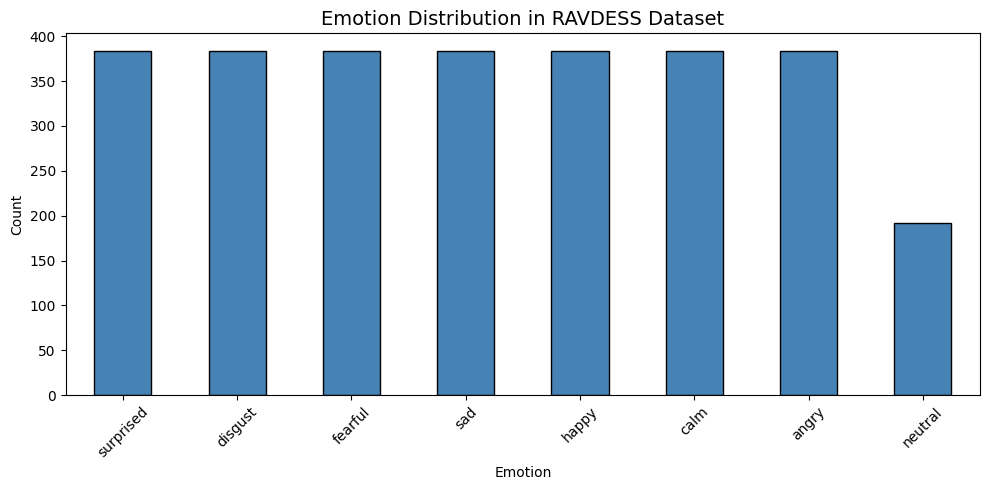

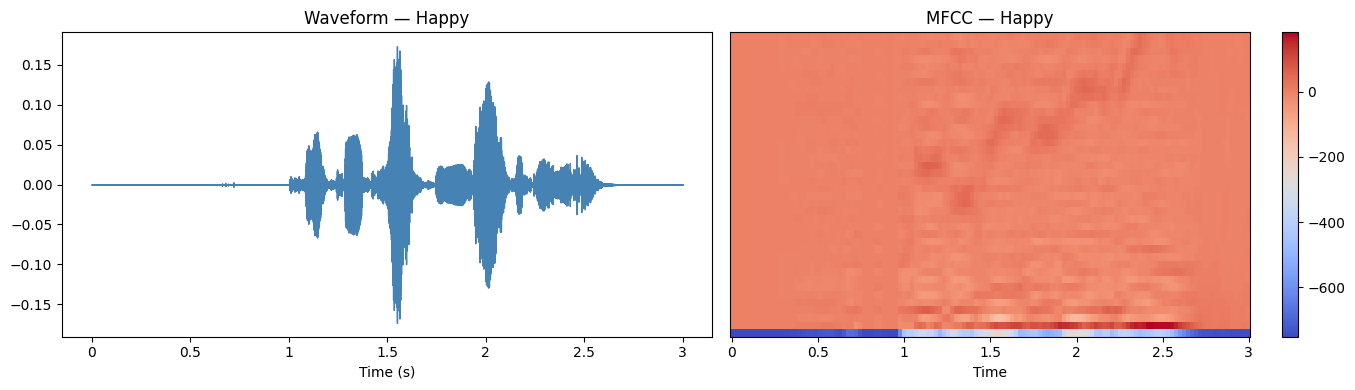

Sample rate: 22050 Hz | Duration: 3.00s


In [4]:
# ── Plot emotion distribution ──
plt.figure(figsize=(10, 5))
df['emotion'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Emotion Distribution in RAVDESS Dataset', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Visualize a sample waveform + spectrogram ──
sample_path = df[df['emotion'] == 'happy']['path'].iloc[0]
y, sr = librosa.load(sample_path, duration=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Waveform
axes[0].set_title('Waveform — Happy')
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Time (s)')

# MFCC
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
img = librosa.display.specshow(mfccs, x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set_title('MFCC — Happy')
fig.colorbar(img, ax=axes[1])

plt.tight_layout()
plt.show()
print(f"Sample rate: {sr} Hz | Duration: {len(y)/sr:.2f}s")

## 🎵 Step 4: Feature Extraction (MFCCs)

**MFCC (Mel-Frequency Cepstral Coefficients)** — captures the tonal quality of voice, widely used in speech processing. We extract 40 MFCC coefficients per audio file and average them over time.

In [5]:
def extract_features(file_path, n_mfcc=40, max_len=174):
    """
    Extract MFCC features from an audio file.
    Returns a fixed-size array of shape (max_len, n_mfcc).
    """
    try:
        # Load audio (3 seconds, 22050 Hz)
        y, sr = librosa.load(file_path, duration=3.0, offset=0.5)

        # Extract MFCCs → shape: (n_mfcc, time_steps)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Pad or truncate to fixed length along time axis
        if mfcc.shape[1] < max_len:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_len]

        # Transpose → shape: (max_len, n_mfcc) — time steps as sequence
        return mfcc.T

    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


# ── Extract features for all files ──
print("⏳ Extracting MFCC features... (this may take 2-5 minutes)")

X = []
y_labels = []

for i, (path, emotion) in enumerate(zip(df['path'], df['emotion'])):
    features = extract_features(path)
    if features is not None:
        X.append(features)
        y_labels.append(emotion)
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(df)} files...")

X = np.array(X)         # shape: (samples, 174, 40)
y_labels = np.array(y_labels)

print(f"\n✅ Feature extraction complete!")
print(f"X shape: {X.shape}")
print(f"Labels shape: {y_labels.shape}")

⏳ Extracting MFCC features... (this may take 2-5 minutes)
  Processed 100/2880 files...
  Processed 200/2880 files...
  Processed 300/2880 files...
  Processed 400/2880 files...
  Processed 500/2880 files...
  Processed 600/2880 files...
  Processed 700/2880 files...
  Processed 800/2880 files...
  Processed 900/2880 files...
  Processed 1000/2880 files...
  Processed 1100/2880 files...
  Processed 1200/2880 files...
  Processed 1300/2880 files...
  Processed 1400/2880 files...
  Processed 1500/2880 files...
  Processed 1600/2880 files...
  Processed 1700/2880 files...
  Processed 1800/2880 files...
  Processed 1900/2880 files...
  Processed 2000/2880 files...
  Processed 2100/2880 files...
  Processed 2200/2880 files...
  Processed 2300/2880 files...
  Processed 2400/2880 files...
  Processed 2500/2880 files...
  Processed 2600/2880 files...
  Processed 2700/2880 files...
  Processed 2800/2880 files...

✅ Feature extraction complete!
X shape: (2880, 174, 40)
Labels shape: (2880,)


## 🏷️ Step 5: Encode Labels & Split Data

In [6]:
# ── Encode string labels to integers ──
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
num_classes = len(le.classes_)

print(f"Emotion classes: {list(le.classes_)}")
print(f"Number of classes: {num_classes}")

# ── One-hot encode for categorical crossentropy ──
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# ── Train/Validation/Test split (70/15/15) ──
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_categorical, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"\n📊 Dataset Split:")
print(f"  Train:      {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test:       {X_test.shape[0]} samples")
print(f"  Input shape per sample: {X_train.shape[1:]}")

Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Number of classes: 8

📊 Dataset Split:
  Train:      2016 samples
  Validation: 432 samples
  Test:       432 samples
  Input shape per sample: (174, 40)


## 🧠 Step 6: Build the CNN + LSTM Model

**Architecture:**
- **Conv1D layers** — extract local patterns from MFCC sequences (like edges in image CNNs)
- **LSTM layer** — captures temporal/sequential dependencies in speech
- **Dense layers** — final classification

In [7]:
def build_model(input_shape, num_classes):
    model = Sequential([

        # ── CNN Block 1 ──
        Conv1D(64, kernel_size=5, activation='relu', padding='same',
               input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── CNN Block 2 ──
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── CNN Block 3 ──
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── LSTM Block ── (captures temporal patterns)
        LSTM(128, return_sequences=False),
        Dropout(0.4),

        # ── Classification Head ──
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Build model
input_shape = (X_train.shape[1], X_train.shape[2])  # (174, 40)
model = build_model(input_shape, num_classes)

model.summary()

I0000 00:00:1777047162.674248      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777047162.680694      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 174, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 174, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 43, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 43, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,200 (1.37 MB)

 Trainable params: 359,304 (1.37 MB)

 Non-trainable params: 896 (3.50 KB)

## 🏋️ Step 7: Train the Model

In [8]:
# ── Callbacks ──
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# ── Train ──
print("🚀 Training started...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("\n✅ Training complete!")

🚀 Training started...
Epoch 1/60


I0000 00:00:1777047168.386550      88 cuda_dnn.cc:529] Loaded cuDNN version 91002


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1556 - loss: 2.0734 - val_accuracy: 0.0880 - val_loss: 2.1684 - learning_rate: 0.0010
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2788 - loss: 1.8556 - val_accuracy: 0.2662 - val_loss: 1.9433 - learning_rate: 0.0010
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3412 - loss: 1.6996 - val_accuracy: 0.3356 - val_loss: 1.7291 - learning_rate: 0.0010
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3731 - loss: 1.5870 - val_accuracy: 0.4792 - val_loss: 1.4479 - learning_rate: 0.0010
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4336 - loss: 1.4479 - val_accuracy: 0.4144 - val_loss: 1.4900 - learning_rate: 0.0010
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4240 - loss: 1.4610 - val_accuracy: 0.4606 - val_loss: 1.3935 - learning_rate: 0.0010
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4814 - loss: 1.3529 - val_accuracy: 0.45

## 📈 Step 8: Plot Training History

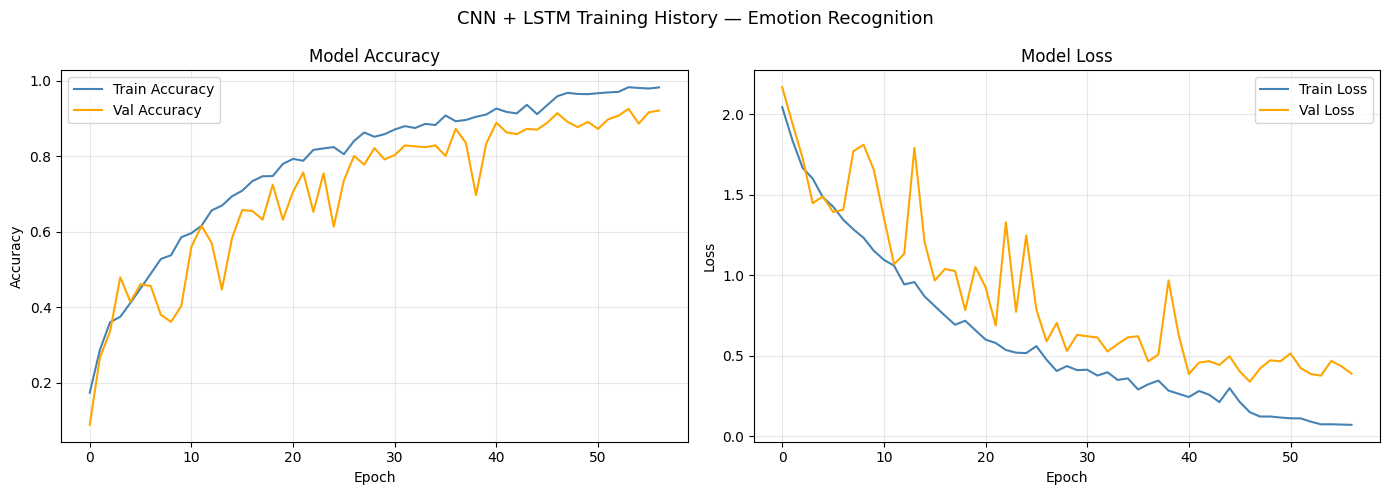

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN + LSTM Training History — Emotion Recognition', fontsize=13)
plt.tight_layout()
plt.show()

## 📊 Step 9: Evaluate on Test Set

In [10]:
# ── Test accuracy ──
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"🎯 Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"📉 Test Loss:     {test_loss:.4f}")

# ── Predictions ──
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# ── Classification Report ──
print("\n📋 Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=le.classes_
))

🎯 Test Accuracy: 92.36%
📉 Test Loss:     0.3211
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

📋 Classification Report:
              precision    recall  f1-score   support

       angry       1.00      0.89      0.94        55
        calm       0.90      0.97      0.93        59
     disgust       0.91      0.94      0.93        53
     fearful       0.88      0.96      0.92        53
       happy       0.96      0.89      0.92        55
     neutral       0.80      1.00      0.89        32
         sad       0.98      0.83      0.90        60
   surprised       0.94      0.94      0.94        65

    accuracy                           0.92       432
   macro avg       0.92      0.93      0.92       432
weighted avg       0.93      0.92      0.92       432



## 🗺️ Step 10: Confusion Matrix

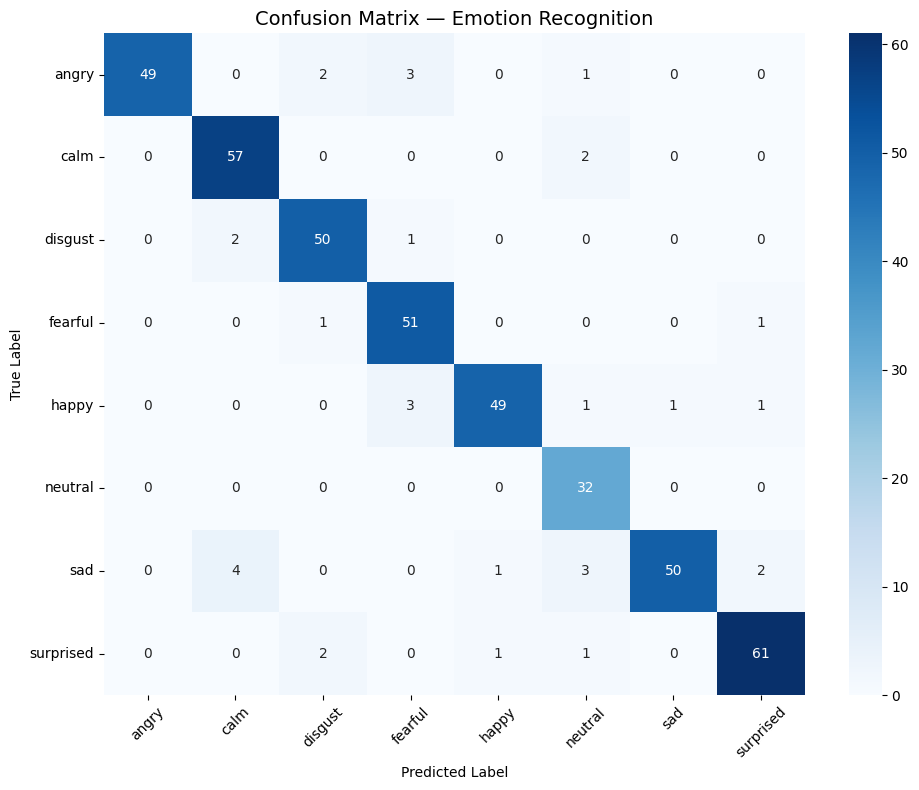

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Emotion Recognition', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 💾 Step 11: Save the Model

In [12]:
# Save model in Keras format
model.save('emotion_recognition_model.keras')
print("✅ Model saved as 'emotion_recognition_model.keras'")

# Save label encoder classes for future use
np.save('label_classes.npy', le.classes_)
print("✅ Label classes saved as 'label_classes.npy'")
print(f"\nClasses: {list(le.classes_)}")

✅ Model saved as 'emotion_recognition_model.keras'
✅ Label classes saved as 'label_classes.npy'

Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


## 🎤 Step 12: Predict on a New Audio File (Demo)

In [13]:
def predict_emotion(file_path, model, label_encoder):
    """
    Predict the emotion from a new audio file.
    """
    features = extract_features(file_path)
    if features is None:
        print("Could not extract features from file.")
        return

    # Reshape for model input: (1, 174, 40)
    features = features.reshape(1, features.shape[0], features.shape[1])

    # Predict
    probs = model.predict(features, verbose=0)[0]
    pred_class = label_encoder.classes_[np.argmax(probs)]
    confidence = np.max(probs) * 100

    print(f"\n🎯 Predicted Emotion: {pred_class.upper()}")
    print(f"📊 Confidence: {confidence:.2f}%")
    print("\nAll probabilities:")
    for emotion, prob in zip(label_encoder.classes_, probs):
        bar = '█' * int(prob * 30)
        print(f"  {emotion:10s}: {bar} {prob*100:.1f}%")

    return pred_class


# ── Test with a sample file from dataset ──
sample_file = df['path'].iloc[0]
actual_emotion = df['emotion'].iloc[0]

print(f"Testing with file: {os.path.basename(sample_file)}")
print(f"Actual emotion: {actual_emotion.upper()}")

predict_emotion(sample_file, model, le)

Testing with file: 03-01-08-01-01-01-02.wav
Actual emotion: SURPRISED

🎯 Predicted Emotion: SURPRISED
📊 Confidence: 99.85%

All probabilities:
  angry     :  0.1%
  calm      :  0.0%
  disgust   :  0.0%
  fearful   :  0.0%
  happy     :  0.1%
  neutral   :  0.0%
  sad       :  0.0%
  surprised : █████████████████████████████ 99.9%


np.str_('surprised')

---
## ✅ Project Summary

| Component | Details |
|---|---|
| **Dataset** | RAVDESS (8 emotions, ~1440 audio files) |
| **Features** | 40 MFCC coefficients, padded to 174 time steps |
| **Model** | CNN (3 blocks) + LSTM + Dense |
| **Regularization** | BatchNorm, Dropout, EarlyStopping, LR Decay |
| **Metrics** | Accuracy, Precision, Recall, F1-Score |
| **Output** | Trained model + confusion matrix + classification report |

### 🔗 GitHub Repository
Upload this notebook to: `CodeAlpha_EmotionRecognition`

### 📱 LinkedIn Post Template
```
🎤 Task 2 Complete — Emotion Recognition from Speech!

Built a CNN + LSTM deep learning model to classify human emotions 
(happy, sad, angry, fearful, etc.) from speech audio using the RAVDESS dataset.

🔧 Tech Stack: Python | Librosa | TensorFlow/Keras | MFCC Features
📊 Model: Conv1D (3 blocks) + LSTM + Dense
🎯 Features: 40 MFCCs extracted from each audio clip

GitHub: [https://github.com/adibasadaf-Tech]

@CodeAlpha #MachineLearning #DeepLearning #SpeechRecognition #AI #Internship
```
---
*CodeAlpha ML Internship — Task 2 | Emotion Recognition from Speech*